In [1]:
import shapely
import matplotlib.pyplot as plt

# Dilate and Erosion

In [2]:
poly1 = shapely.geometry.Polygon([(0, 0), (1, 0), (1, 2), (0.8, 2), (0.8, 1), (0, 1)])
line1 = shapely.geometry.LineString([(0, 0), (0.5, 0.5), (1, 0)])

For dilation use positive `distance` parameter in `buffer` method. For erosion use negative `distance` parameter in `buffer` method.

## Dilation

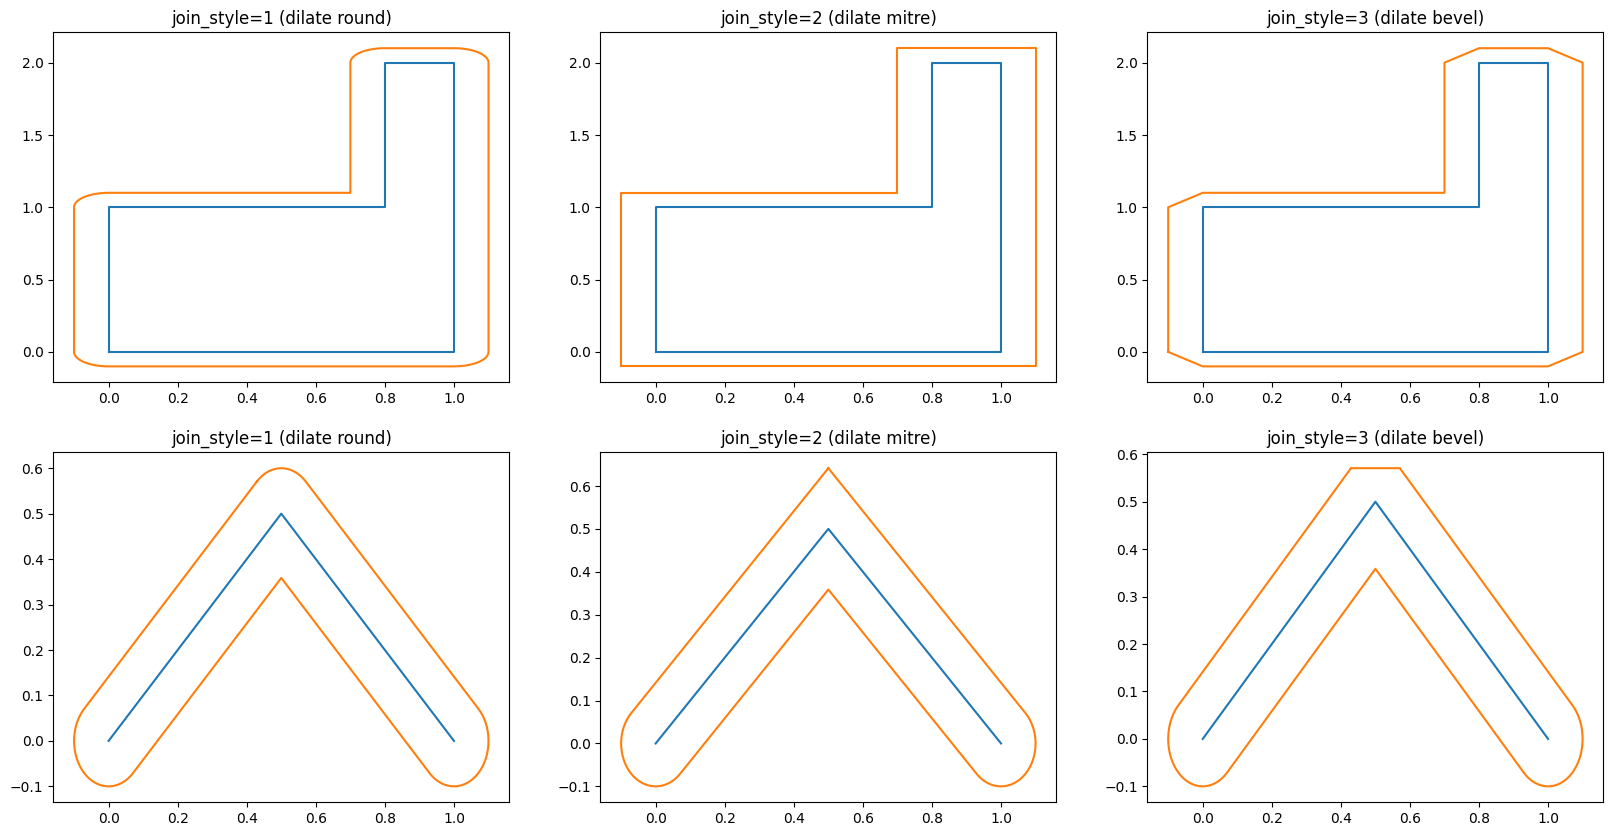

In [3]:
plt.figure(figsize=(20, 10))
plt.subplot(2, 3, 1)
plt.plot(*poly1.exterior.xy)
plt.plot(*poly1.buffer(0.1, join_style=1).exterior.xy)
plt.title('join_style=1 (dilate round)')
plt.subplot(2, 3, 2)
plt.plot(*poly1.exterior.xy)
plt.plot(*poly1.buffer(0.1, join_style=2).exterior.xy)
plt.title('join_style=2 (dilate mitre)')
plt.subplot(2, 3, 3)
plt.plot(*poly1.exterior.xy)
plt.plot(*poly1.buffer(0.1, join_style=3).exterior.xy)
plt.title('join_style=3 (dilate bevel)')
plt.subplot(2, 3, 4)
plt.plot(*line1.xy)
plt.plot(*line1.buffer(0.1, join_style=1).exterior.xy)
plt.title('join_style=1 (dilate round)')
plt.subplot(2, 3, 5)
plt.plot(*line1.xy)
plt.plot(*line1.buffer(0.1, join_style=2).exterior.xy)
plt.title('join_style=2 (dilate mitre)')
plt.subplot(2, 3, 6)
plt.plot(*line1.xy)
plt.plot(*line1.buffer(0.1, join_style=3).exterior.xy)
plt.title('join_style=3 (dilate bevel)')
plt.show()

To change dilation style for loose ends we should use parameter `cap_style`.

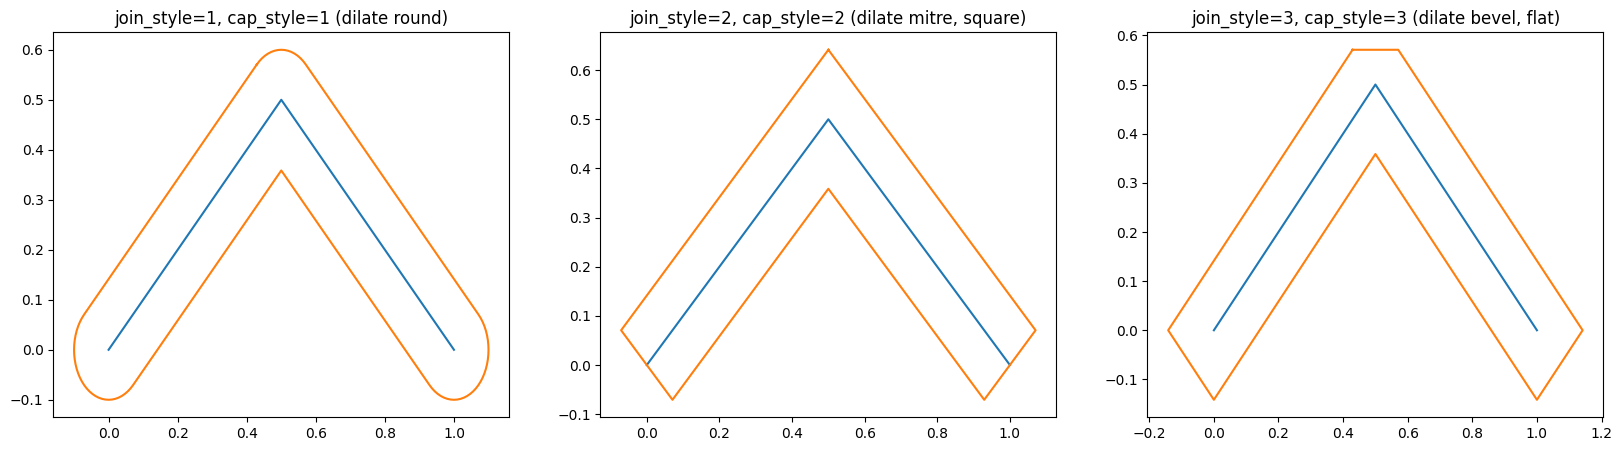

In [4]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.plot(*line1.xy)
plt.plot(*line1.buffer(0.1, join_style=1, cap_style=1).exterior.xy)
plt.title('join_style=1, cap_style=1 (dilate round)')
plt.subplot(1, 3, 2)
plt.plot(*line1.xy)
plt.plot(*line1.buffer(0.1, join_style=2, cap_style=2).exterior.xy)
plt.title('join_style=2, cap_style=2 (dilate mitre, square)')
plt.subplot(1, 3, 3)
plt.plot(*line1.xy)
plt.plot(*line1.buffer(0.1, join_style=3, cap_style=3).exterior.xy)
plt.title('join_style=3, cap_style=3 (dilate bevel, flat)')
plt.show()

## Erosion

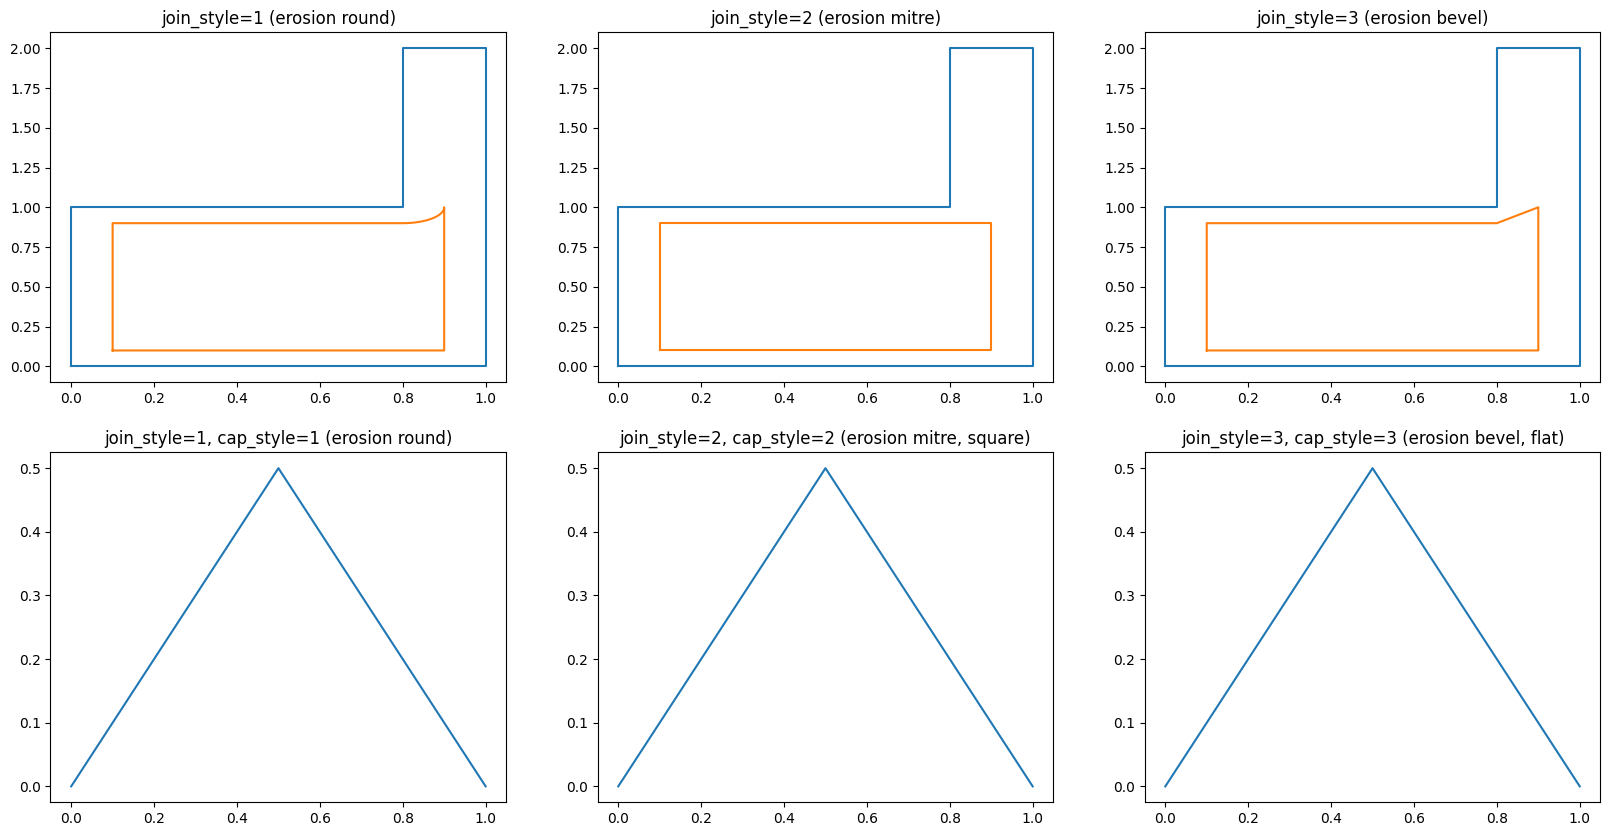

In [5]:
plt.figure(figsize=(20, 10))
plt.subplot(2, 3, 1)
plt.plot(*poly1.exterior.xy)
plt.plot(*poly1.buffer(-0.1, join_style=1).exterior.xy)
plt.title('join_style=1 (erosion round)')
plt.subplot(2, 3, 2)
plt.plot(*poly1.exterior.xy)
plt.plot(*poly1.buffer(-0.1, join_style=2).exterior.xy)
plt.title('join_style=2 (erosion mitre)')
plt.subplot(2, 3, 3)
plt.plot(*poly1.exterior.xy)
plt.plot(*poly1.buffer(-0.1, join_style=3).exterior.xy)
plt.title('join_style=3 (erosion bevel)')
plt.subplot(2, 3, 4)
plt.plot(*line1.xy)
plt.plot(*line1.buffer(-0.1, join_style=1, cap_style=1).exterior.xy)
plt.title('join_style=1, cap_style=1 (erosion round)')
plt.subplot(2, 3, 5)
plt.plot(*line1.xy)
plt.plot(*line1.buffer(-0.1, join_style=2, cap_style=2).exterior.xy)
plt.title('join_style=2, cap_style=2 (erosion mitre, square)')
plt.subplot(2, 3, 6)
plt.plot(*line1.xy)
plt.plot(*line1.buffer(-0.1, join_style=3, cap_style=3).exterior.xy)
plt.title('join_style=3, cap_style=3 (erosion bevel, flat)')
plt.show()

# Collision types

In [35]:
primitives = {
    'poly1': shapely.geometry.Polygon([(0, 0), (1, 0), (1, 2), (0.8, 2), (0.8, 1), (0, 1)]),
    'poly2': shapely.geometry.Polygon([(0.1, 0), (0.5, 0), (0.5, 0.5), (0.1, 0.5)]),
    'poly3': shapely.geometry.Polygon([(0.6, 0.25), (0.8, 0.25), (0.8, 0.5), (0.6, 0.5)]),
    'poly4': shapely.geometry.Polygon([(0.8, 0.75), (0.9, 0.75), (0.9, 1), (0.8, 1)]),
    'poly5': shapely.geometry.Polygon([(0, 1.25), (0.2, 1.25), (0.2, 1.5), (0, 1.5)]),
    'poly6': shapely.geometry.Polygon([(1.0, 1.0), (1.2, 1.0), (1.2, 1.5), (1.0, 1.5)]),
    'poly7': shapely.geometry.Polygon([(1.0, 2.0), (1.2, 2.0), (1.2, 2.5), (1.0, 2.5)]),
    'poly8': shapely.geometry.Polygon([(0.7, 1.25), (0.9, 1.25), (0.9, 1.5), (0.7, 1.5)]),
    'line1': shapely.geometry.LineString([(0.2, 1.0), (0.5, 1.0)]),
    'line2': shapely.geometry.LineString([(0.8, 0.6), (1.2, 0.6)]),
}

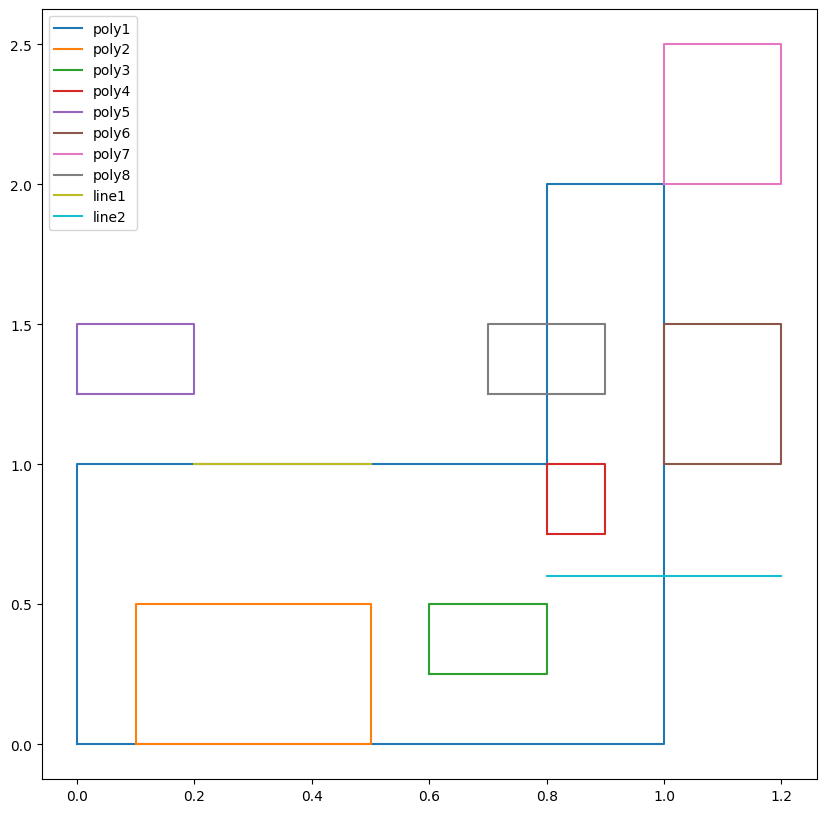

In [36]:
plt.figure(figsize=(10, 10))
for name, prim in primitives.items():
    if type(prim) is shapely.geometry.Polygon:
        plt.plot(*prim.exterior.xy, label=name)
    elif type(prim) is shapely.geometry.LineString:
        plt.plot(*prim.xy, label=name)
plt.legend()
plt.show()

## Contains

Returns `True` if no points of `__other__` lie in the exterior of the object and at least one point of the interior of `__other__` lies in the interior of object.

In [37]:
for name, poly in primitives.items():
    if primitives['poly1'].contains(poly):
        print(f'poly1 contains {name}')
    else:
        print(f'poly1 does not contain {name}')

poly1 contains poly1
poly1 contains poly2
poly1 contains poly3
poly1 contains poly4
poly1 does not contain poly5
poly1 does not contain poly6
poly1 does not contain poly7
poly1 does not contain poly8
poly1 does not contain line1
poly1 does not contain line2


## Covers

Returns `True` if every point of `__other__` is a point on the interior or boundary of object. This is similar to `object.contains(__other__)` except that this does not require any interior points of other to lie in the interior of object.

In [38]:
for name, poly in primitives.items():
    if primitives['poly1'].covers(poly):
        print(f'poly1 covers {name}')
    else:
        print(f'poly1 does not cover {name}')

poly1 covers poly1
poly1 covers poly2
poly1 covers poly3
poly1 covers poly4
poly1 does not covers poly5
poly1 does not covers poly6
poly1 does not covers poly7
poly1 does not covers poly8
poly1 covers line1
poly1 does not covers line2


## Covered by
`object.covered_by(other)`:

Returns `True` if every point of object is a point on the interior or boundary of `__other__`. This is equivalent to `__other__.covers(object)`.

## Crosses

Returns `True` if the interior of the object intersects the interior of the `__other__` but does not contain it, and the dimension of the intersection is less than the dimension of the one or the `__other__`.

In [39]:
for name, poly in primitives.items():
    if primitives['poly1'].crosses(poly):
        print(f'poly1 crosses {name}')
    else:
        print(f'poly1 does not cross {name}')

poly1 does not crosses poly1
poly1 does not crosses poly2
poly1 does not crosses poly3
poly1 does not crosses poly4
poly1 does not crosses poly5
poly1 does not crosses poly6
poly1 does not crosses poly7
poly1 does not crosses poly8
poly1 does not crosses line1
poly1 crosses line2


## Disjoint

Returns `True` if the boundary and interior of the object do not intersect at all with those of the `__other__`.

In [41]:
for name, poly in primitives.items():
    if primitives['poly1'].disjoint(poly):
        print(f'poly1 is disjoint with {name}')
    else:
        print(f'poly1 isn`t disjoint with {name}')

poly1 isn`t disjoint with poly1
poly1 isn`t disjoint with poly2
poly1 isn`t disjoint with poly3
poly1 isn`t disjoint with poly4
poly1 is disjoint with poly5
poly1 isn`t disjoint with poly6
poly1 isn`t disjoint with poly7
poly1 isn`t disjoint with poly8
poly1 isn`t disjoint with line1
poly1 isn`t disjoint with line2


## Intersects

Returns `True` if the boundary or interior of the object intersect in any way with those of the `__other__`.

In [43]:
for name, poly in primitives.items():
    if primitives['poly1'].intersects(poly):
        print(f'poly1 intersects {name}')
    else:
        print(f'poly1 does not intersect {name}')

poly1 intersects poly1
poly1 intersects poly2
poly1 intersects poly3
poly1 intersects poly4
poly1 does not intersect poly5
poly1 intersects poly6
poly1 intersects poly7
poly1 intersects poly8
poly1 intersects line1
poly1 intersects line2


## Overlaps

Returns `True` if the geometries have more than one but not all points in common, have the same dimension, and the intersection of the interiors of the geometries has the same dimension as the geometries themselves.

In [44]:
for name, poly in primitives.items():
    if primitives['poly1'].overlaps(poly):
        print(f'poly1 overlaps {name}')
    else:
        print(f'poly1 does not overlap {name}')

poly1 does not overlap poly1
poly1 does not overlap poly2
poly1 does not overlap poly3
poly1 does not overlap poly4
poly1 does not overlap poly5
poly1 does not overlap poly6
poly1 does not overlap poly7
poly1 overlaps poly8
poly1 does not overlap line1
poly1 does not overlap line2


## Touches

Returns `True` if the objects have at least one point in common and their interiors do not intersect with any part of the `__other__`.

In [45]:
for name, poly in primitives.items():
    if primitives['poly1'].touches(poly):
        print(f'poly1 touches {name}')
    else:
        print(f'poly1 does not touch {name}')

poly1 does not touch poly1
poly1 does not touch poly2
poly1 does not touch poly3
poly1 does not touch poly4
poly1 does not touch poly5
poly1 touches poly6
poly1 touches poly7
poly1 does not touch poly8
poly1 touches line1
poly1 does not touch line2


## Within

Returns `True` if the object’s boundary and interior intersect only with the interior of the `__other__` (not its boundary or exterior).

In [47]:
for name, poly in primitives.items():
    if poly.within(primitives['poly1']):
        print(f'{name} is within poly1')
    else:
        print(f'{name} is not within poly1')

poly1 is within poly1
poly2 is within poly1
poly3 is within poly1
poly4 is within poly1
poly5 is not within poly1
poly6 is not within poly1
poly7 is not within poly1
poly8 is not within poly1
line1 is not within poly1
line2 is not within poly1


# Use [DE-9IM](https://en.wikipedia.org/wiki/DE-9IM) to create my own criteria

Criteria checks that `geom1` is inside `geom2` and `geom1` do not touch `geom2` boundary.

In [59]:
def lies_only_in_interior(geom1, geom2):
    rel = geom1.relate(geom2)
    return rel[0] != 'F' and rel[1] == 'F' and rel[2] == 'F' and rel[4] == 'F'

for name, poly in primitives.items():
    if lies_only_in_interior(poly, primitives['poly1']):
        print(f'{name} is within poly1')
    else:
        print(f'{name} is not within poly1')

poly1 is not within poly1
poly2 is not within poly1
poly3 is within poly1
poly4 is not within poly1
poly5 is not within poly1
poly6 is not within poly1
poly7 is not within poly1
poly8 is not within poly1
line1 is not within poly1
line2 is not within poly1


Criteria checks that `geom1` contains `geom2` and `geom1` do not touch `geom2` boundary.

In [62]:
def contains_only_in_interior(geom1, geom2):
    rel = geom1.relate(geom2)
    return rel[0] != 'F' and rel[3] == 'F' and rel[6] == 'F' and rel[4] == 'F'

for name, poly in primitives.items():
    if contains_only_in_interior(primitives['poly1'], poly):
        print(f'poly1 contains {name}')
    else:
        print(f'poly1 does not contain {name}')

poly1 does not contain poly1
poly1 does not contain poly2
poly1 contains poly3
poly1 does not contain poly4
poly1 does not contain poly5
poly1 does not contain poly6
poly1 does not contain poly7
poly1 does not contain poly8
poly1 does not contain line1
poly1 does not contain line2
